In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import joblib

In [15]:
df = pd.read_csv('../dataset/raw/air_pollution_china.csv')

df = df.sort_values(by=['Year', 'Month', 'Hour']).reset_index(drop=True)

features = ['PM2.5 (µg/m³)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Pressure (hPa)']
data = df[features].fillna(method='ffill')

C:\Users\LENOVO TP T470\AppData\Local\Temp\ipykernel_15004\2202014387.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = df[features].fillna(method='ffill')


In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

joblib.dump(scaler, '../models/scaler_polusi.pkl')

['../models/scaler_polusi.pkl']

In [17]:
def create_sliding_window(dataset, time_steps=24):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), :])
        y.append(dataset[i + time_steps, 0])  
    return np.array(X), np.array(y)

time_steps = 24
X, y = create_sliding_window(scaled_data, time_steps)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [18]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

C:\Users\LENOVO TP T470\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - loss: 0.0975 - val_loss: 0.0778
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0860 - val_loss: 0.0800
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0866 - val_loss: 0.0777
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0852 - val_loss: 0.0820
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0840 - val_loss: 0.0784
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0858 - val_loss: 0.0784
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0854 - val_loss: 0.0776
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0849 - val_loss: 0.0802
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0849 - val_loss: 0.0779
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0834 - val_loss: 0.0777
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0839 - val_loss: 0.0778
Epoch 12/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.

In [22]:
model.save('models/model_polusi_lstm.h5')
joblib.dump(scaler, 'models/scaler_polusi.pkl')

['models/scaler_polusi.pkl']

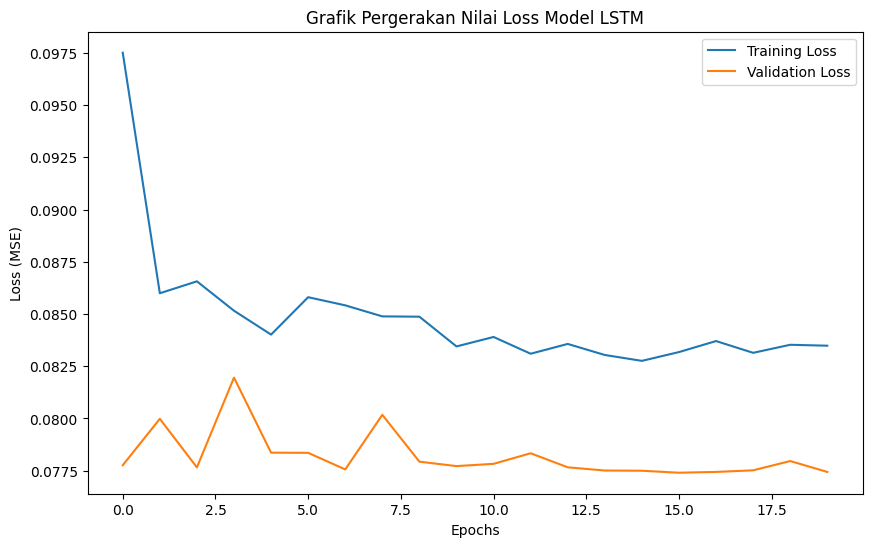

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Pergerakan Nilai Loss Model LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [23]:
print(scaler.n_features_in_)
# dan
print(df.columns.tolist())  # kolom apa yang dipakai untuk scaling

5
['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Wind Direction (°)', 'Pressure (hPa)', 'Precipitation (mm)', 'Visibility (km)', 'AQI', 'Season', 'City', 'Latitude', 'Longitude', 'Day of Week', 'Hour', 'Month', 'Year', 'Weather Condition', 'Station ID']


In [24]:
print(X_train.shape)

(2380, 24, 5)
